In [1]:
import numpy as np
import h5py
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True

DATA_DIR = Path('../rect_small_tight_200hz_2026-04-06')  # adjust to your path

with open(DATA_DIR / 'dataset_index.yaml', 'r') as f:
    index = yaml.safe_load(f)

successful = [e for e in index if e['success']]
failed = [e for e in index if not e['success']]
print(f'Total: {len(index)} | Success: {len(successful)} ({100*len(successful)/len(index):.0f}%) | Failed: {len(failed)}')

Total: 3827 | Success: 2486 (65%) | Failed: 1341


In [11]:
def load_episode(path):
    """Load all groups from an episode HDF5 into a flat dict."""
    data = {}
    with h5py.File(path, 'r') as f:
        for group in f.keys():
            if isinstance(f[group], h5py.Group):
                for k in f[group].keys():
                    data[f'{group}/{k}'] = f[group][k][()]
    return data

# Load one successful episode for inspection
ep = load_episode(DATA_DIR / successful[10]['path'])
ts = ep['obs/timestamps']
t = ts - ts[0]
print(f"Episode {successful[0]['episode_id']}: {len(t)} steps, {t[-1]:.2f}s")
print(f"Shapes: f_ext={ep['obs/f_ext'].shape}, f_internal={ep['obs/f_internal'].shape}, ee_vel={ep['obs/ee_velocity'].shape}, Fff={ep['action/Fff'].shape}")

Episode 0: 3058 steps, 15.28s
Shapes: f_ext=(3058, 6), f_internal=(3058, 6), ee_vel=(3058, 6), Fff=(3058, 6)


## 1. Obs-action alignment check
Fff XY (commanded wiggle) vs f_ext XY (contact response). The sinusoidal command should lead, with f_ext following with a slight lag. If they're anti-correlated or shifted by exactly one step, the recording alignment is off.

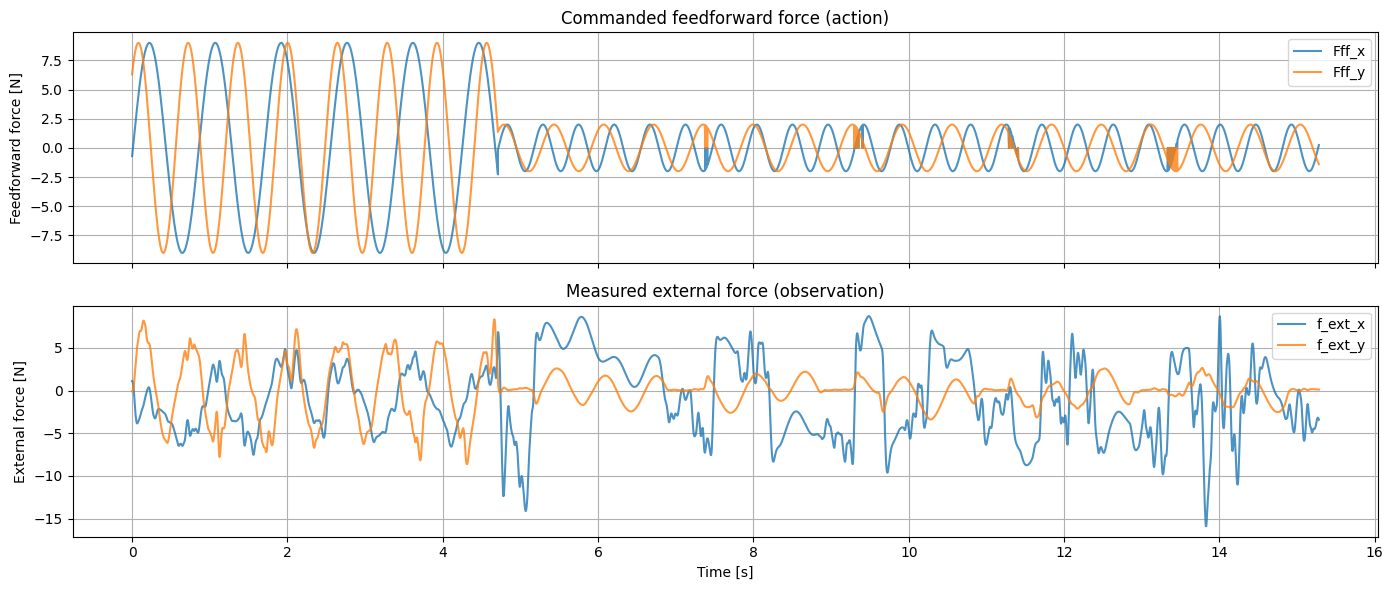

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(t, ep['action/Fff'][:, 0], label='Fff_x', alpha=0.8)
axes[0].plot(t, ep['action/Fff'][:, 1], label='Fff_y', alpha=0.8)
axes[0].set_ylabel('Feedforward force [N]')
axes[0].legend()
axes[0].set_title('Commanded feedforward force (action)')

axes[1].plot(t, ep['obs/f_ext'][:, 0], label='f_ext_x', alpha=0.8)
axes[1].plot(t, ep['obs/f_ext'][:, 1], label='f_ext_y', alpha=0.8)
axes[1].set_ylabel('External force [N]')
axes[1].set_xlabel('Time [s]')
axes[1].legend()
axes[1].set_title('Measured external force (observation)')

plt.tight_layout()

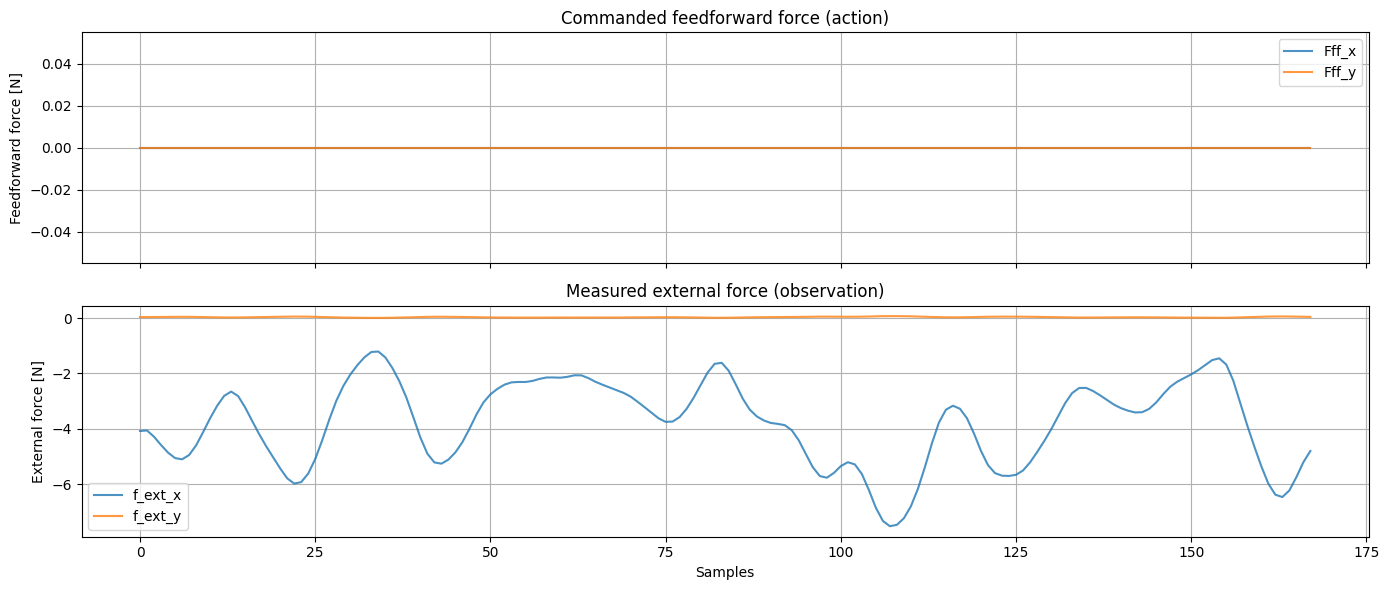

In [4]:
start, stop = 1500, 2000
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(ep['action/Fff'][start:stop, 0], label='Fff_x', alpha=0.8)
axes[0].plot(ep['action/Fff'][start:stop, 1], label='Fff_y', alpha=0.8)
axes[0].set_ylabel('Feedforward force [N]')
axes[0].legend()
axes[0].set_title('Commanded feedforward force (action)')

axes[1].plot(ep['obs/f_ext'][start:stop, 0], label='f_ext_x', alpha=0.8)
axes[1].plot(ep['obs/f_ext'][start:stop, 1], label='f_ext_y', alpha=0.8)
axes[1].set_ylabel('External force [N]')
axes[1].set_xlabel('Samples')
axes[1].legend()
axes[1].set_title('Measured external force (observation)')

plt.tight_layout()

## 2. Z-axis force and insertion progress
Fff_z should be the constant downward press. Peg tip z should decrease monotonically during insertion. If peg tip stalls while Fff_z is active, the peg is stuck — the expert should be wiggling at that point.

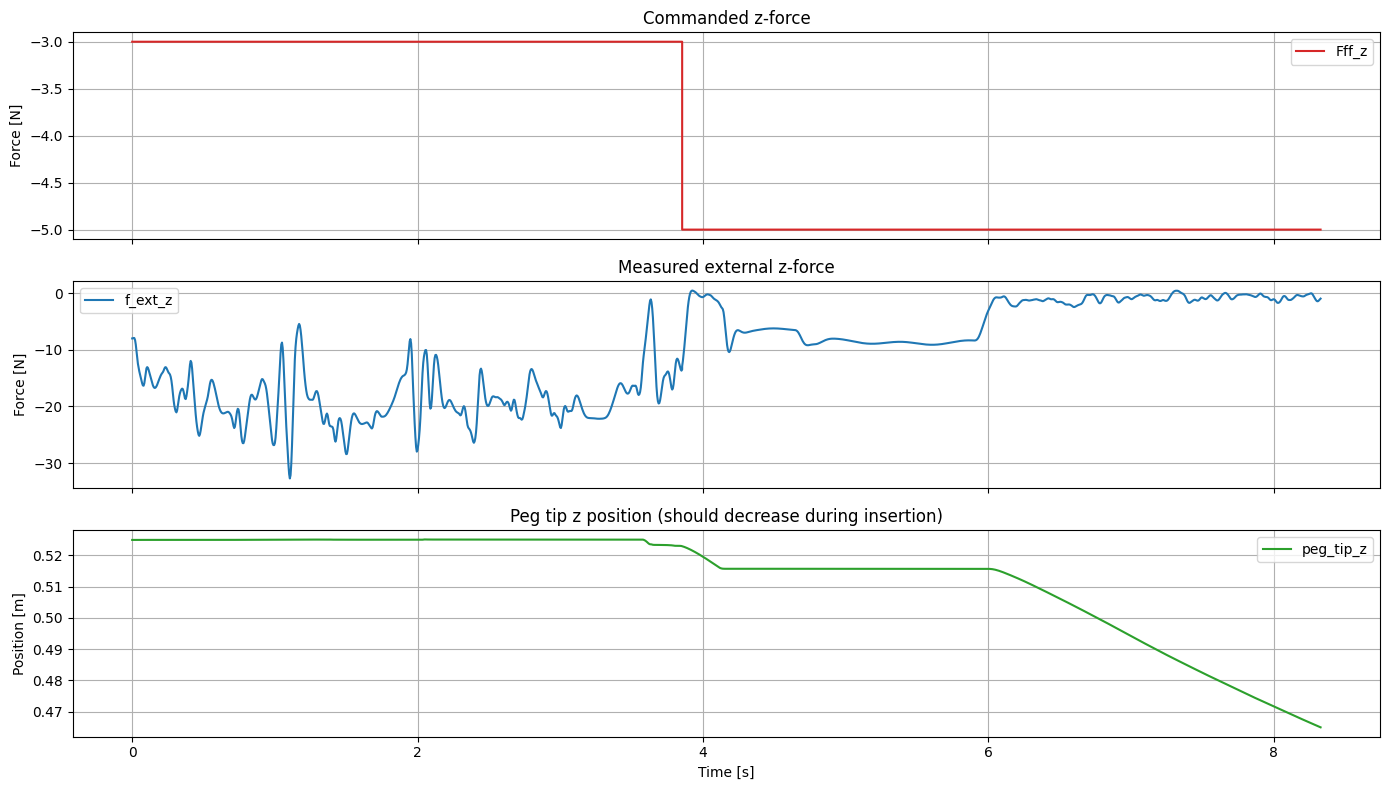

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t, ep['action/Fff'][:, 2], label='Fff_z', color='tab:red')
axes[0].set_ylabel('Force [N]')
axes[0].legend()
axes[0].set_title('Commanded z-force')

axes[1].plot(t, ep['obs/f_ext'][:, 2], label='f_ext_z', color='tab:blue')
axes[1].set_ylabel('Force [N]')
axes[1].legend()
axes[1].set_title('Measured external z-force')

peg_z = ep['debug/peg_tip_pos'][:, 2]
axes[2].plot(t, peg_z, label='peg_tip_z', color='tab:green')
axes[2].set_ylabel('Position [m]')
axes[2].set_xlabel('Time [s]')
axes[2].legend()
axes[2].set_title('Peg tip z position (should decrease during insertion)')

plt.tight_layout()

## 3. Full 6D wrench profiles
All action and observation force/torque channels for one episode. Look for: reasonable magnitudes, no NaN/inf spikes, torque channels active during wiggle.

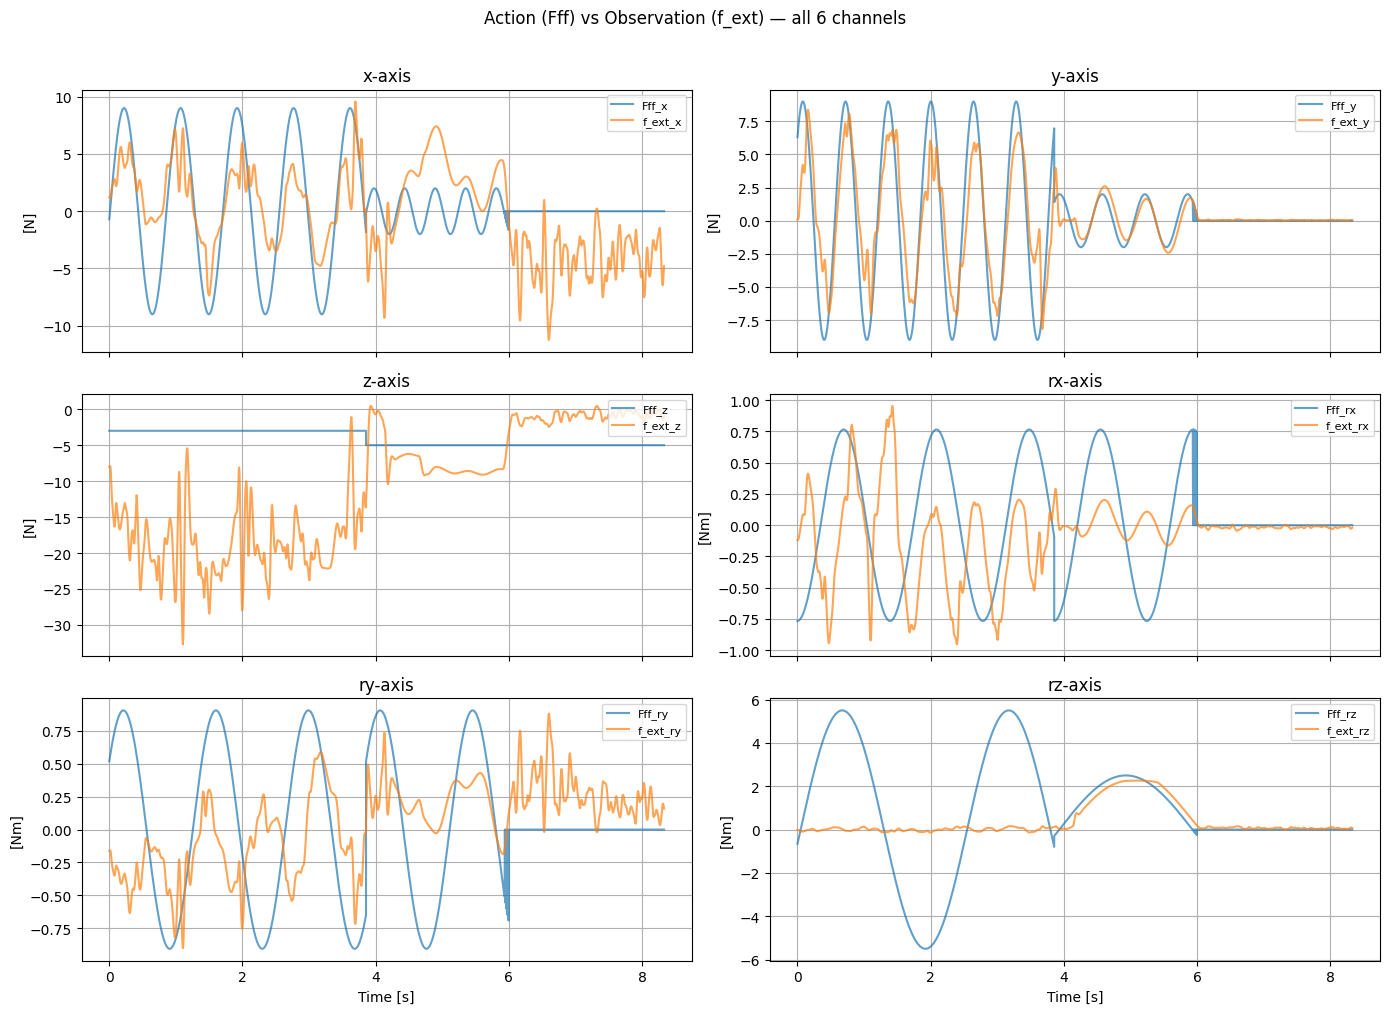

In [6]:
labels = ['x', 'y', 'z', 'rx', 'ry', 'rz']

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
for i in range(6):
    ax = axes[i // 2, i % 2]
    ax.plot(t, ep['action/Fff'][:, i], label=f'Fff_{labels[i]}', alpha=0.7)
    ax.plot(t, ep['obs/f_ext'][:, i], label=f'f_ext_{labels[i]}', alpha=0.7)
    ax.set_ylabel('[N]' if i < 3 else '[Nm]')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_title(f'{labels[i]}-axis')

axes[2, 0].set_xlabel('Time [s]')
axes[2, 1].set_xlabel('Time [s]')
fig.suptitle('Action (Fff) vs Observation (f_ext) — all 6 channels', y=1.01)
plt.tight_layout()

## 4. Behavior phase via mode signal
Verify the expert policy phases are recorded and transitions make sense.

Unique modes: [1]


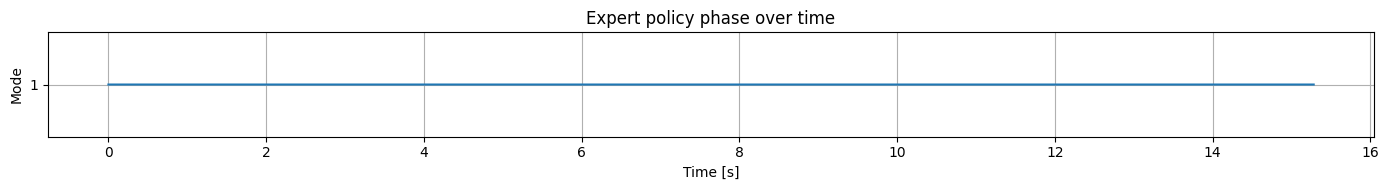

In [13]:
mode = ep['debug/mode']
unique_modes = np.unique(mode)
print(f'Unique modes: {unique_modes}')

fig, ax = plt.subplots(figsize=(14, 2))
ax.plot(t, mode, drawstyle='steps-post')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Mode')
ax.set_title('Expert policy phase over time')
ax.set_yticks(unique_modes)
plt.tight_layout()

## 5. Cross-episode statistics
Distribution of episode durations and step counts across successful episodes. Outliers here might indicate stuck episodes that technically succeeded but took abnormally long.

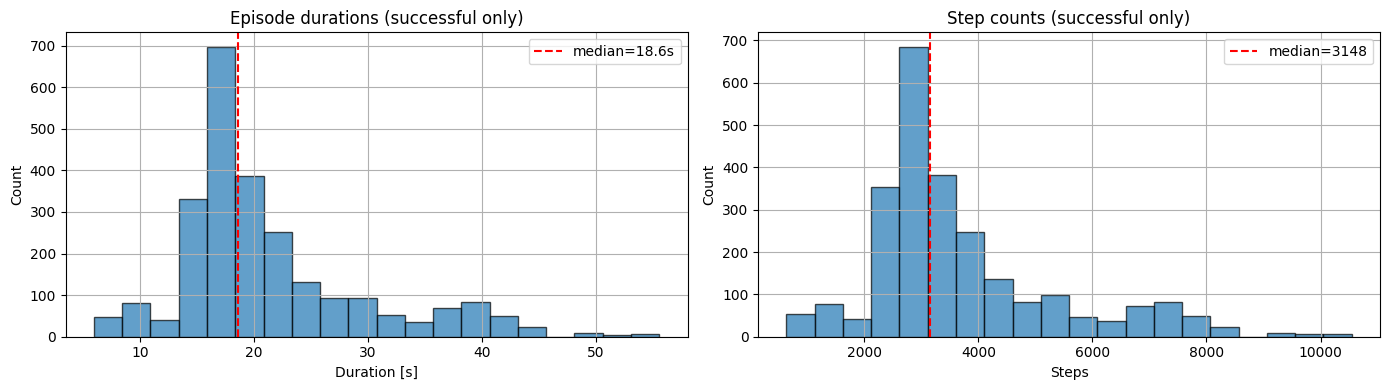

In [8]:
durations = [e['duration'] for e in successful]
step_counts = [e['n_steps'] for e in successful]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(durations, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(np.median(durations), color='red', linestyle='--', label=f'median={np.median(durations):.1f}s')
axes[0].set_xlabel('Duration [s]')
axes[0].set_ylabel('Count')
axes[0].set_title('Episode durations (successful only)')
axes[0].legend()

axes[1].hist(step_counts, bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(np.median(step_counts), color='red', linestyle='--', label=f'median={np.median(step_counts):.0f}')
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('Count')
axes[1].set_title('Step counts (successful only)')
axes[1].legend()

plt.tight_layout()

## 6. Normalization sanity check
After normalizing, each channel should be roughly zero-mean with unit variance. Spot-check on one episode.

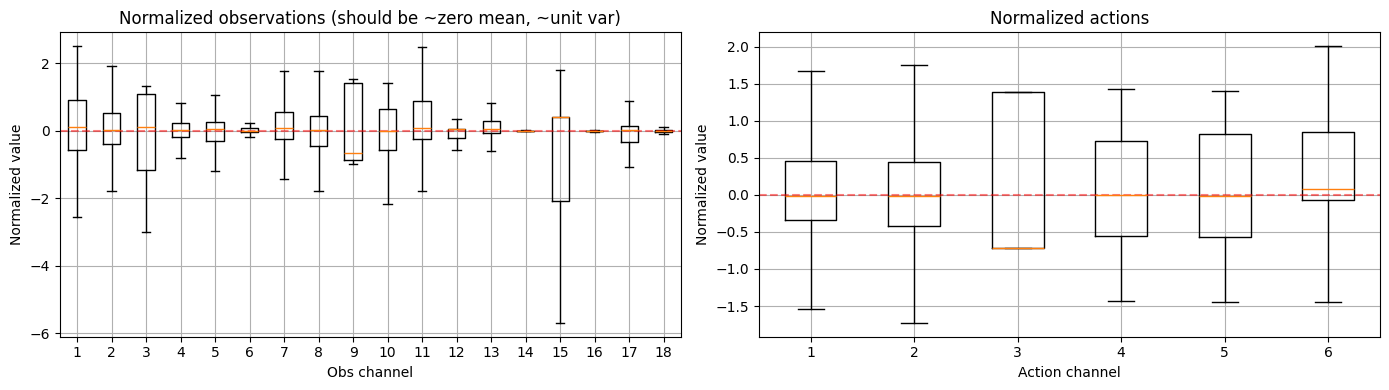

In [10]:
norm_path = Path('../configs/normalization_stats.yaml')  # adjust if running from different location

with open(norm_path, 'r') as f:
    stats = yaml.safe_load(f)

obs_mean = np.array(stats['obs_mean'])
obs_std = np.array(stats['obs_std'])
action_mean = np.array(stats['action_mean'])
action_std = np.array(stats['action_std'])

obs_raw = np.concatenate([ep['obs/f_ext'], ep['obs/f_internal'], ep['obs/ee_velocity']], axis=1)
obs_norm = (obs_raw - obs_mean) / (obs_std + 1e-6)
act_norm = (ep['action/Fff'] - action_mean) / (action_std + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].boxplot(obs_norm, showfliers=False)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Obs channel')
axes[0].set_ylabel('Normalized value')
axes[0].set_title('Normalized observations (should be ~zero mean, ~unit var)')

axes[1].boxplot(act_norm, showfliers=False)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Action channel')
axes[1].set_ylabel('Normalized value')
axes[1].set_title('Normalized actions')

plt.tight_layout()

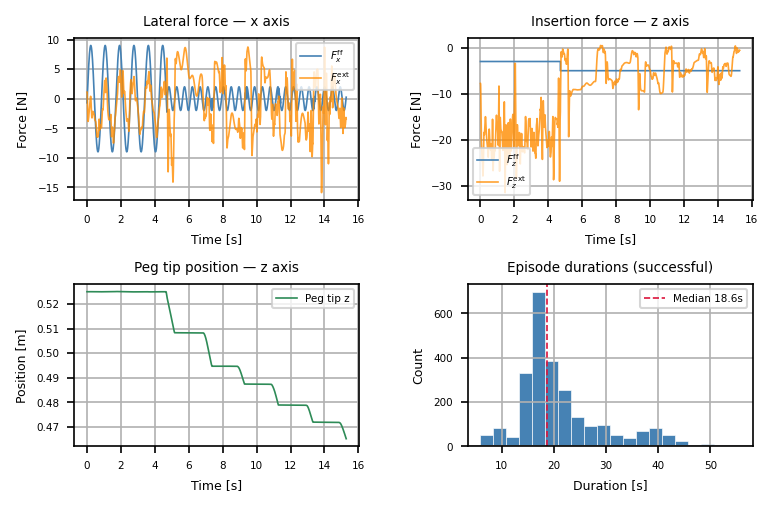

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── pick a representative successful episode ──────────────────────────────────
ep = load_episode(DATA_DIR / successful[10]['path'])
ts = ep['obs/timestamps']
t  = ts - ts[0]

Fff      = ep['action/Fff']          # (N, 6)
f_ext    = ep['obs/f_ext']           # (N, 6)
peg_z    = ep['debug/peg_tip_pos'][:, 2]

# ── episode duration distribution (successful only) ───────────────────────────
durations = np.array([e['duration'] for e in successful])

# ── figure: 520 x 340 pt → use inches at 100 dpi ─────────────────────────────
fig = plt.figure(figsize=(5.20, 3.40), dpi=150)
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        left=0.10, right=0.97,
                        top=0.93,  bottom=0.13,
                        hspace=0.52, wspace=0.38)

ax_x   = fig.add_subplot(gs[0, 0])
ax_z   = fig.add_subplot(gs[0, 1])
ax_pos = fig.add_subplot(gs[1, 0])
ax_dur = fig.add_subplot(gs[1, 1])

# ── shared style ──────────────────────────────────────────────────────────────
LABEL_FS  = 6
TICK_FS   = 5
TITLE_FS  = 6.5
LEGEND_FS = 5
LW        = 0.8

# ── top-left: x feedforward + measured ───────────────────────────────────────
ax_x.plot(t, Fff[:, 0],   lw=LW, color='steelblue',  label=r'$F^\mathrm{ff}_x$')
ax_x.plot(t, f_ext[:, 0], lw=LW, color='darkorange',
          alpha=0.8,       label=r'$F^\mathrm{ext}_x$')
ax_x.set_title('Lateral force — x axis', fontsize=TITLE_FS)
ax_x.set_xlabel('Time [s]', fontsize=LABEL_FS)
ax_x.set_ylabel('Force [N]', fontsize=LABEL_FS)
ax_x.tick_params(labelsize=TICK_FS)
ax_x.legend(fontsize=LEGEND_FS, loc='upper right')

# ── top-right: z feedforward + measured ──────────────────────────────────────
ax_z.plot(t, Fff[:, 2],   lw=LW, color='steelblue',  label=r'$F^\mathrm{ff}_z$')
ax_z.plot(t, f_ext[:, 2], lw=LW, color='darkorange',
          alpha=0.8,       label=r'$F^\mathrm{ext}_z$')
ax_z.set_title('Insertion force — z axis', fontsize=TITLE_FS)
ax_z.set_xlabel('Time [s]', fontsize=LABEL_FS)
ax_z.set_ylabel('Force [N]', fontsize=LABEL_FS)
ax_z.tick_params(labelsize=TICK_FS)
ax_z.legend(fontsize=LEGEND_FS, loc='lower left')

# ── bottom-left: peg tip z position ──────────────────────────────────────────
ax_pos.plot(t, peg_z, lw=LW, color='seagreen', label='Peg tip z')
ax_pos.set_title('Peg tip position — z axis', fontsize=TITLE_FS)
ax_pos.set_xlabel('Time [s]', fontsize=LABEL_FS)
ax_pos.set_ylabel('Position [m]', fontsize=LABEL_FS)
ax_pos.tick_params(labelsize=TICK_FS)
ax_pos.legend(fontsize=LEGEND_FS)

# ── bottom-right: episode duration histogram ──────────────────────────────────
ax_dur.hist(durations, bins=20, color='steelblue', edgecolor='white', linewidth=0.3)
ax_dur.axvline(np.median(durations), color='crimson', linestyle='--',
               lw=LW, label=f'Median {np.median(durations):.1f}s')
ax_dur.set_title('Episode durations (successful)', fontsize=TITLE_FS)
ax_dur.set_xlabel('Duration [s]', fontsize=LABEL_FS)
ax_dur.set_ylabel('Count', fontsize=LABEL_FS)
ax_dur.tick_params(labelsize=TICK_FS)
ax_dur.legend(fontsize=LEGEND_FS)

# ── save ──────────────────────────────────────────────────────────────────────
fig.savefig('expert_data_overview.svg', format='svg', bbox_inches='tight')
fig.savefig('expert_data_overview.png', format='png', dpi=300, bbox_inches='tight')
plt.show()